In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("cleaned_data.csv")

In [ ]:
df.shape

(36662, 5)

In [ ]:
df.head()

,Unnamed: 0,clean_comment,category,word_count,num_stop_words
0,0,family mormon never tried explain still stare ...,1,39,13
1,1,buddhism much lot compatible christianity espe...,1,196,59
2,2,seriously say thing first get complex explain ...,-1,86,40
3,3,learned want teach different focus goal not wr...,0,29,15
4,4,benefit may want read living buddha living chr...,1,112,45


In [5]:
df.drop(columns=["Unnamed: 0"] , inplace=True)

In [ ]:
df.head()

,clean_comment,category,word_count,num_stop_words
0,family mormon never tried explain still stare ...,1,39,13
1,buddhism much lot compatible christianity espe...,1,196,59
2,seriously say thing first get complex explain ...,-1,86,40
3,learned want teach different focus goal not wr...,0,29,15
4,benefit may want read living buddha living chr...,1,112,45


In [ ]:
df["clean_comment"].isna().sum()

np.int64(0)

First we will use embeddings

In [30]:
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Embedding , Dense , GlobalAveragePooling1D , Dropout
from keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [7]:
MAX_WORDS = 20000
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_comment"])

We are keeping only top 20,000 frequent words

In [8]:
len(tokenizer.word_index)

48175

In [9]:
sequences = tokenizer.texts_to_sequences(df["clean_comment"])

Converted all sentences into vectors and the size of vectors are already stored in column 'word_count'

In [10]:
df["word_count"].describe()

,word_count
count,36662.000000
mean,29.744149
std,56.869053
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


In [11]:
df["word_count"].quantile([0.90, 0.95, 0.99])

,word_count
0.90,68.0
0.95,102.0
0.99,258.0


So almost 95% words have length less than 100. So for each sentence we will have dimension 100

In [12]:
MAX_LEN = 100

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [13]:
X.shape

(36662, 100)

In [14]:
X[0]

array([  145, 17714,    66,   570,   782,    48,  9853, 14512,    13,
          13,     6,   194,  3823,  7193,  6760,    46,  2892,  4913,
       17715,  9854,  5800,  4051,  1322,    17,  1367,  1753,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0], dtype=int32)

In [15]:
label_map = {-1: 0, 0: 1, 1: 2}
y = df["category"].map(label_map).values

In [16]:
np.unique(y)

array([0, 1, 2])

For larger comments we are only keeping first 100 words well it is not optimal but good starting point we are doing this because neural network expect input to be of same shape

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
X_train.shape

(29329, 100)

In [19]:
y_train.shape

(29329,)

In [20]:
X_test.shape

(7333, 100)

In [21]:
y_test.shape

(7333,)

In [32]:
model = Sequential([
    Embedding(
        input_dim = 20000,
        output_dim = 256,
        input_length = 100
    ),

    GlobalAveragePooling1D(),

    Dense(64 , activation = "relu"),
    Dropout(0.3),

    Dense(3 , activation = "softmax"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
model.build(input_shape=(None, 100))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 256)       │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,136,643 (19.59 MB)

 Trainable params: 5,136,643 (19.59 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model1.keras" , save_best_only=True , monitor = "val_accuracy")
]
model.compile(
    optimizer = Adam(0.0005),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

history1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=128,
    callbacks = callbacks
)

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4982 - loss: 1.0138 - val_accuracy: 0.5824 - val_loss: 0.9362
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6033 - loss: 0.8820 - val_accuracy: 0.5732 - val_loss: 0.8807
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6551 - loss: 0.7814 - val_accuracy: 0.4701 - val_loss: 0.9143
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7373 - loss: 0.6562 - val_accuracy: 0.6678 - val_loss: 0.7433
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8024 - loss: 0.5307 - val_accuracy: 0.6911 - val_loss: 0.7172
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8336 - loss: 0.4612 - val_accuracy: 0.7506 - val_loss: 0.5981
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8652 - loss: 0.3881 - val_accuracy: 0.7743 - val_loss: 0.6044
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8887 - loss: 0.3340 - val_accuracy: 0

In [35]:
ann_model = keras.models.load_model("model1.keras")

In [36]:
ann_model.evaluate(X_test , y_test)

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8362 - loss: 0.5870


[0.5870034694671631, 0.836219847202301]

Well we got an accuracy of 83.62% which is close to ml's best model but here we can achieve better

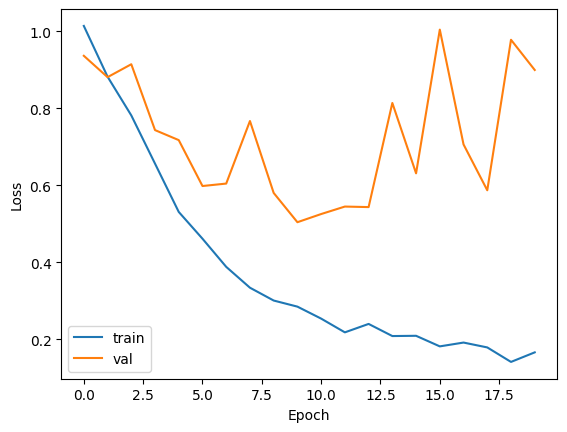

In [37]:
plt.plot(history1.history["loss"], label="train")
plt.plot(history1.history["val_loss"], label="val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

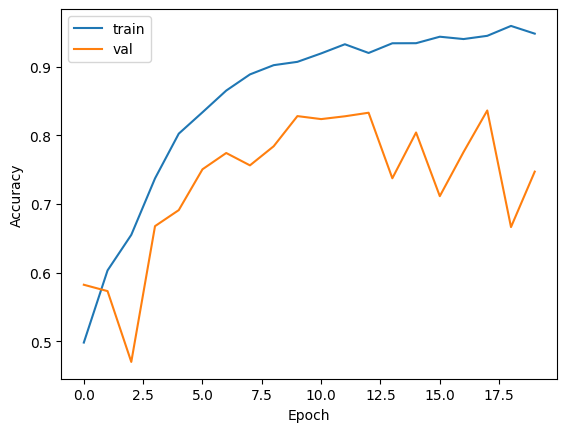

In [38]:
import matplotlib.pyplot as plt

plt.plot(history1.history["accuracy"], label="train")
plt.plot(history1.history["val_accuracy"], label="val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [39]:
preds = ann_model.predict(X_test).argmax(axis=1)

print(classification_report(y_test, preds))

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      1650
           1       0.84      0.93      0.88      2529
           2       0.89      0.82      0.85      3154

    accuracy                           0.84      7333
   macro avg       0.82      0.82      0.82      7333
weighted avg       0.84      0.84      0.84      7333



Well this model also producing same pattern as SVM since there are lesser negative comments it is expected so now we will train with class_weights

In [40]:
model = Sequential([
    Embedding(
        input_dim = 20000,
        output_dim = 256,
        input_length = 100
    ),

    GlobalAveragePooling1D(),

    Dense(64 , activation = "relu"),
    Dropout(0.3),

    Dense(3 , activation = "softmax"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [41]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(1.481711629786804), np.int64(1): np.float64(0.9665183720547043), np.int64(2): np.float64(0.7749154512787995)}


We can clearly see that negative class have larger class weight

In [42]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model1_classweights.keras" , save_best_only=True , monitor="val_accuracy")
]
model.compile(
    optimizer = Adam(0.0005),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

history1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=128,
    callbacks = callbacks
)

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4996 - loss: 1.0151 - val_accuracy: 0.5863 - val_loss: 0.9472
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5894 - loss: 0.8949 - val_accuracy: 0.6298 - val_loss: 0.8540
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6580 - loss: 0.7847 - val_accuracy: 0.6720 - val_loss: 0.7640
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7498 - loss: 0.6408 - val_accuracy: 0.7138 - val_loss: 0.6735
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7855 - loss: 0.5591 - val_accuracy: 0.7015 - val_loss: 0.6969
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8357 - loss: 0.4591 - val_accuracy: 0.7492 - val_loss: 0.6668
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8585 - loss: 0.4043 - val_accuracy: 0.8185 - val_loss: 0.5303
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8777 - loss: 0.3610 - val_accuracy: 0

In [43]:
ann_model_weights = keras.models.load_model("model1_classweights.keras")

In [44]:
ann_model_weights.evaluate(X_test , y_test)

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8449 - loss: 0.5201


[0.5201022624969482, 0.8449475169181824]

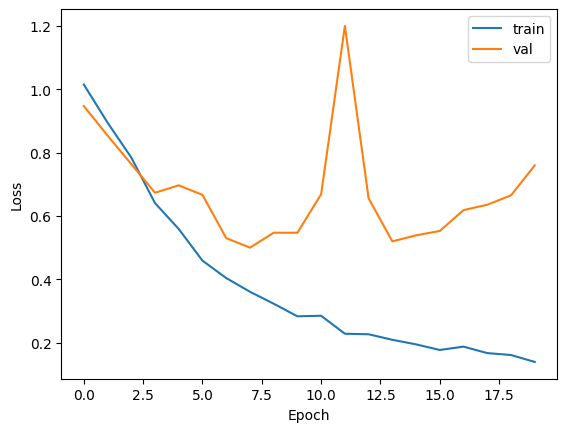

In [45]:
plt.plot(history1.history["loss"], label="train")
plt.plot(history1.history["val_loss"], label="val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

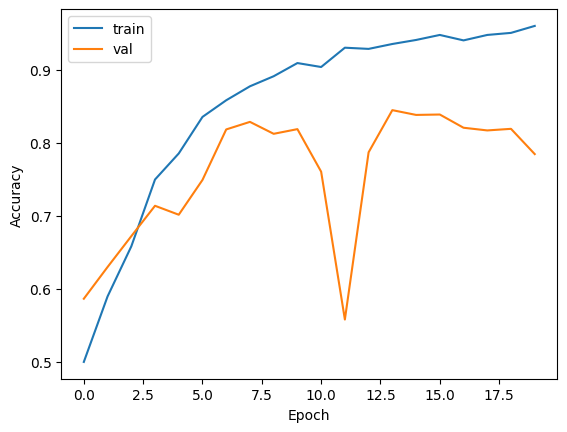

In [46]:
plt.plot(history1.history["accuracy"], label="train")
plt.plot(history1.history["val_accuracy"], label="val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [47]:
preds = ann_model_weights.predict(X_test).argmax(axis=1)

print(classification_report(y_test, preds))

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.76      0.71      0.74      1650
           1       0.86      0.92      0.89      2529
           2       0.87      0.85      0.86      3154

    accuracy                           0.84      7333
   macro avg       0.83      0.83      0.83      7333
weighted avg       0.84      0.84      0.84      7333



Accuracy is slightly increased

Now we will use LSTM which are specifically designed for this kind of purpose sequence modelling as of now the models we are dealing doesn't quite respect sequence of words but LSTM do that

In [24]:
from keras.layers import LSTM, Bidirectional, Embedding, Dense, Dropout, SpatialDropout1D

model = Sequential([
    Embedding(
        input_dim=20000,
        output_dim=128,
        mask_zero=True
    ),

    SpatialDropout1D(0.4),

    Bidirectional(LSTM(
        128,
        dropout=0.4,
    )),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(3, activation="softmax")
])

model.compile(
    optimizer=Adam(0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "lstm_model.keras", save_best_only=True, monitor="val_accuracy"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=128,
    callbacks = callbacks,
    class_weight = class_weights
)

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5794 - loss: 0.9014 - val_accuracy: 0.7773 - val_loss: 0.5960 - learning_rate: 5.0000e-04
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8284 - loss: 0.4966 - val_accuracy: 0.8314 - val_loss: 0.4713 - learning_rate: 5.0000e-04
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8901 - loss: 0.3347 - val_accuracy: 0.8414 - val_loss: 0.4363 - learning_rate: 5.0000e-04
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9187 - loss: 0.2598 - val_accuracy: 0.8437 - val_loss: 0.4701 - learning_rate: 5.0000e-04
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9344 - loss: 0.2172 - val_accuracy: 0.8396 - val_loss: 0.5048 - learning_rate: 5.0000e-04
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9437 - loss: 0.1843 - val_accuracy: 0.8384 - val_loss: 0.5221 - learning_rate: 5.0000e-04
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - ac

In [25]:
lstm_model = keras.models.load_model("lstm_model.keras")

In [26]:
lstm_model.evaluate(X_test , y_test)

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8437 - loss: 0.4701


[0.4701182246208191, 0.8437201976776123]

We got an accuracy of 84.37% by using LSTM

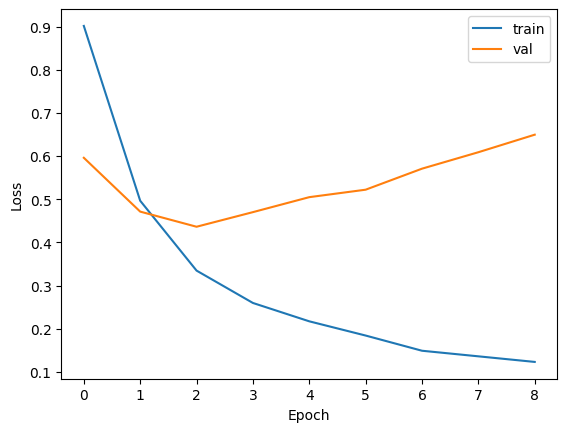

In [27]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

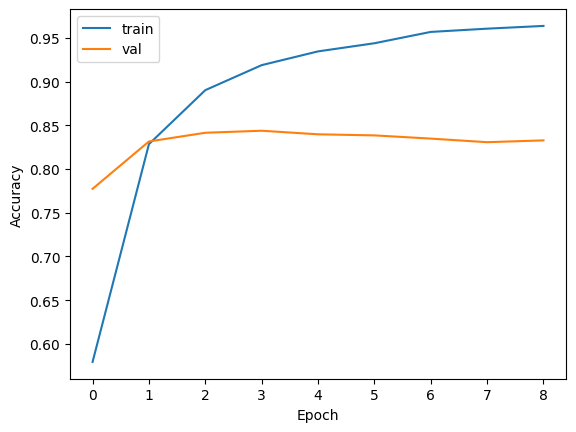

In [28]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [48]:
preds = lstm_model.predict(X_test).argmax(axis=1)

print(classification_report(y_test, preds))

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1650
           1       0.87      0.91      0.89      2529
           2       0.87      0.85      0.86      3154

    accuracy                           0.84      7333
   macro avg       0.83      0.83      0.83      7333
weighted avg       0.84      0.84      0.84      7333

